## **Credit Card Fraud Detection**
##### Using Ensemble Modeling and Imbalance Handling to Catch Rare Fraud Cases

## Business Problem
A bank wants to automatically flag potentially fraudulent credit card 
transactions in real time. Missing real fraud costs the bank money 
directly; flagging too many legitimate transactions as fraud annoys 
customers and increases manual review workload.

**Goal:** Build a model that catches as much real fraud as possible, 
while keeping false alarms manageable.

**Business question we're answering:**
"Can we accurately flag fraudulent transactions despite fraud being 
extremely rare, without overwhelming the fraud review team with false alarms?"

-----------------------------------------------------------
## About the Data
-----------------------------------------------------------
- Dataset: Credit Card Fraud Detection (real, anonymized, Sept 2013)
- Size: 284,807 transactions, 492 fraud cases (0.173%)
- Features: Time, V1-V28 (anonymized via PCA by data provider), Amount, Class

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
fraud = pd.read_csv("./data/creditcard.csv")

In [3]:
fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
fraud.shape

(284807, 31)

In [5]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

-----------------------------------------------------------
## Data Preprocessing
-----------------------------------------------------------

In [6]:
# Handle missing values
fraud.isnull().sum().sum()

np.int64(0)

In [7]:
print("Duplicates found:", fraud.duplicated().sum())
fraud = fraud.drop_duplicates()
print("Shape after removing duplicates:", fraud.shape)

Duplicates found: 1081
Shape after removing duplicates: (283726, 31)


In [8]:
print(fraud[['Time', 'Amount']].describe())
print("\nSkewness:")
print(fraud[['Time', 'Amount']].skew().round(2))

                Time         Amount
count  283726.000000  283726.000000
mean    94811.077600      88.472687
std     47481.047891     250.399437
min         0.000000       0.000000
25%     54204.750000       5.600000
50%     84692.500000      22.000000
75%    139298.000000      77.510000
max    172792.000000   25691.160000

Skewness:
Time      -0.04
Amount    16.98
dtype: float64


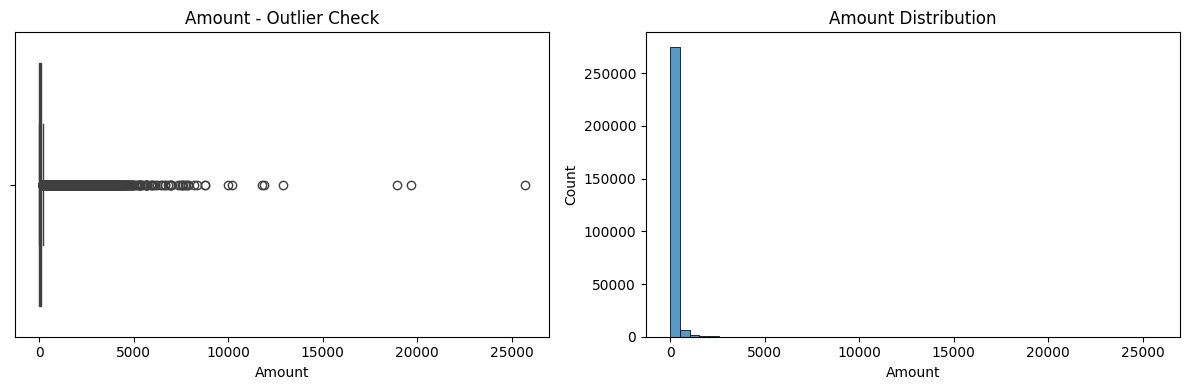

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=fraud['Amount'])  
plt.title('Amount - Outlier Check')

plt.subplot(1, 2, 2)
sns.histplot(fraud['Amount'], bins=50)
plt.title('Amount Distribution')

plt.tight_layout()
plt.savefig('outputs/amount_check.png', dpi=150, bbox_inches='tight')
plt.show()

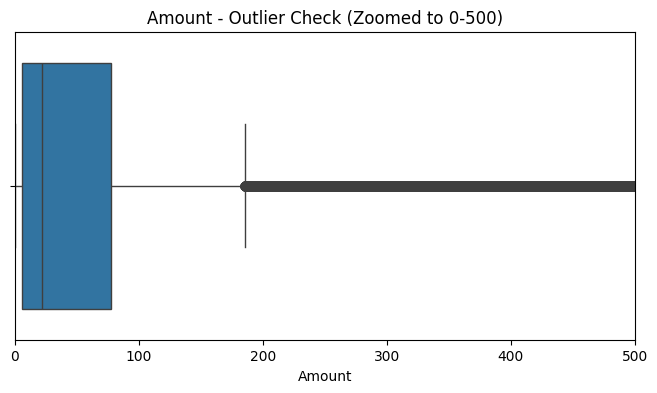

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=fraud['Amount'])
plt.xlim(0, 500)   # zoom into the region where most transactions live
plt.title('Amount - Outlier Check (Zoomed to 0-500)')
plt.savefig('outputs/amount_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

print(fraud['Amount'].describe())

**DECISION**:   
We do NOT remove large-Amount outliers or log-transform here.
An unusually large transaction can itself be a real
fraud signal -- removing or compressing it could delete the exact
pattern we're trying to detect. Our main models (Random Forest,
XGBoost, LightGBM) are also tree-based and don't require scaling or
a symmetric distribution to work correctly.

-----------------------------------------------------------
## Exploratory Data Analysis
-----------------------------------------------------------

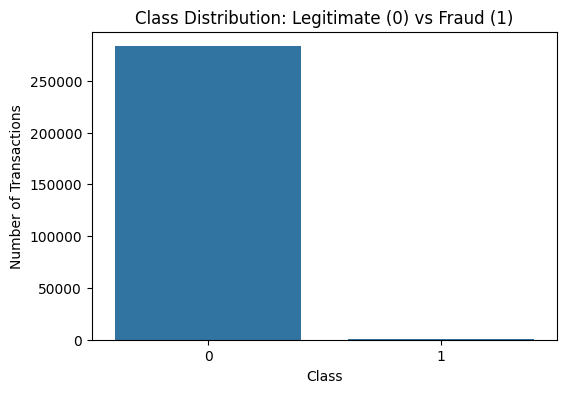

Class
0    283253
1       473
Name: count, dtype: int64
Fraud percentage: 0.167 %


In [11]:
# The core problem of this project: how extreme is the imbalance?
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=fraud)
plt.title('Class Distribution: Legitimate (0) vs Fraud (1)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.savefig('outputs/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(fraud['Class'].value_counts())
print("Fraud percentage:", round(fraud['Class'].mean() * 100, 3), "%")

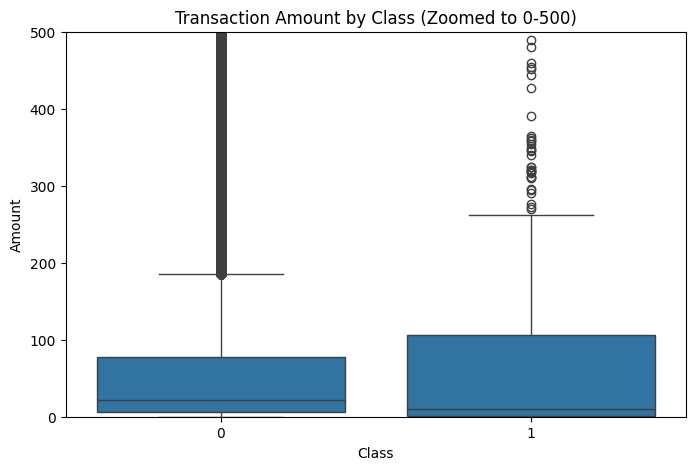

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [12]:
# Does transaction amount differ between fraud and legitimate transactions?
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=fraud)
plt.ylim(0, 500)
plt.title('Transaction Amount by Class (Zoomed to 0-500)')
plt.savefig('outputs/amount_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

print(fraud.groupby('Class')['Amount'].describe())

In [13]:
# Zero-amount transactions and fraud concentration
zero_amount_count = (fraud['Amount'] == 0).sum()
fraud_rate_overall = fraud['Class'].mean() * 100
fraud_rate_zero_amount = fraud[fraud['Amount'] == 0]['Class'].mean() * 100
 
print(f"Zero-amount transactions: {zero_amount_count}")
print(fraud[fraud['Amount'] == 0]['Class'].value_counts())
print("-----------------------------")
print(f"Overall fraud rate: {fraud_rate_overall:.3f}%")
print(f"Fraud rate among $0 transactions: {fraud_rate_zero_amount:.3f}%")
print(f"Ratio: {fraud_rate_zero_amount / fraud_rate_overall:.2f}x higher")

Zero-amount transactions: 1808
Class
0    1783
1      25
Name: count, dtype: int64
-----------------------------
Overall fraud rate: 0.167%
Fraud rate among $0 transactions: 1.383%
Ratio: 8.29x higher


**Finding:**  
$0 transactions show a fraud rate ~8x higher than the overall
average -- consistent with fraudsters testing a stolen card's
validity with a $0 authorization before a larger fraudulent charge.

V17     -0.313498
V14     -0.293375
V12     -0.250711
V10     -0.206971
V16     -0.187186
V3      -0.182322
V7      -0.172347
V18     -0.105340
V1      -0.094486
V9      -0.094021
V5      -0.087812
V6      -0.043915
V24     -0.007210
V23     -0.006333
V13     -0.003897
V15     -0.003300
V25      0.003202
V26      0.004265
V22      0.004887
V28      0.009682
V20      0.021486
V27      0.021892
V21      0.026357
V8       0.033068
V19      0.033631
V2       0.084624
V4       0.129326
V11      0.149067
Class    1.000000
Name: Class, dtype: float64


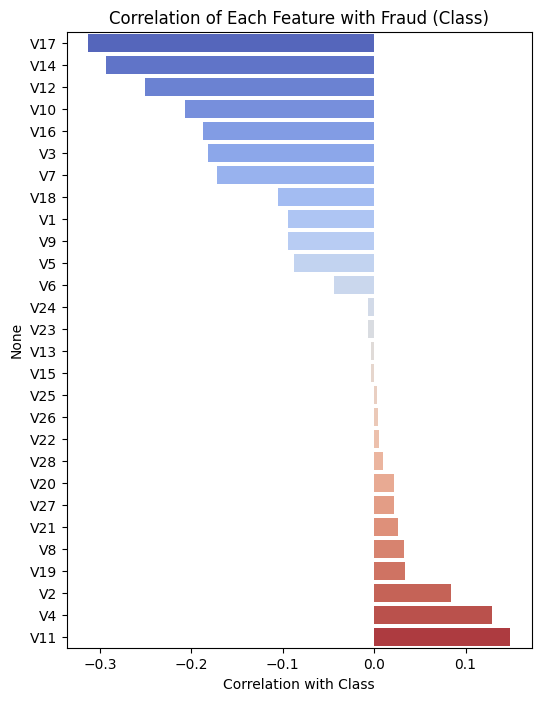

In [14]:
# Correlation between anonymized features (V1-V28) and fraud
correlations = fraud.drop(['Amount', 'Time'], axis=1).corr()['Class'].sort_values()
print(correlations)
 
plt.figure(figsize=(6, 8))
sns.barplot(x=correlations.drop('Class').values, y=correlations.drop('Class').index,
            hue=correlations.drop('Class').index, palette='coolwarm', legend=False)
plt.title('Correlation of Each Feature with Fraud (Class)')
plt.xlabel('Correlation with Class')
plt.savefig('outputs/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:**   
V17, V14, V12, V10 show the strongest correlation with fraud
(negative direction); V11, V4, V2 show the strongest positive
correlation. We'll compare this later against model feature importances.

In [15]:
X = fraud.drop('Class', axis=1)
y = fraud['Class']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

print("Training set fraud rate:", round(y_train.mean() * 100, 3), "%")
print("Test set fraud rate:", round(y_test.mean() * 100, 3), "%")

Training set fraud rate: 0.167 %
Test set fraud rate: 0.167 %


-----------------------------------------------------------
## FEATURE SCALING
-----------------------------------------------------------

In [16]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test_scaled[['Amount_scaled', 'Time_scaled']] = scaler.transform(X_test[['Amount', 'Time']])

X_train_tree = X_train
X_test_tree = X_test

X_train_lr = X_train_scaled.drop(['Amount', 'Time'], axis=1)
X_test_lr = X_test_scaled.drop(['Amount', 'Time'], axis=1)

---------------------------------------------------------------------
## Baseline Model: Why Accuracy Alone Is Misleading
---------------------------------------------------------------------
Before building anything sophisticated, we fit a simple Logistic 
Regression with no imbalance handling, to demonstrate concretely why 
accuracy is a dangerous metric on this dataset.

In [17]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_lr, y_train)

y_pred_baseline = baseline_model.predict(X_test_lr)

print("Accuracy:", round(accuracy_score(y_test, y_pred_baseline) * 100, 3), "%")

Accuracy: 99.914 %


In [18]:
print("\nPredicted class counts:")
print(pd.Series(y_pred_baseline).value_counts())

print("\nActual test set class counts:")
print(y_test.value_counts())


Predicted class counts:
0    56680
1       66
Name: count, dtype: int64

Actual test set class counts:
Class
0    56651
1       95
Name: count, dtype: int64


[[56641    10]
 [   39    56]]


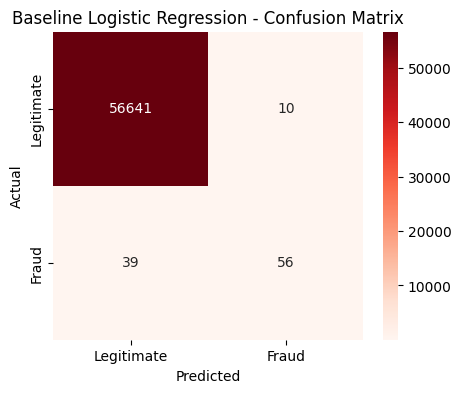

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [19]:
cm = confusion_matrix(y_test, y_pred_baseline)
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline Logistic Regression - Confusion Matrix')
plt.savefig('outputs/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_baseline, target_names=['Legitimate', 'Fraud']))

### Baseline Model Finding

The baseline Logistic Regression achieved 99.91% accuracy — but this 
number is misleading. Looking at the confusion matrix and classification 
report instead:

- **Fraud Recall: 0.59** — the model missed 39 out of 95 real fraud 
  cases (41% of all fraud went undetected)
- **Fraud Precision: 0.85** — when the model did flag something as 
  fraud, it was right 85% of the time
- **Accuracy was near-perfect purely because 99.83% of transactions 
  are legitimate** — a model could achieve similarly high accuracy 
  even by performing poorly on fraud specifically, since fraud barely 
  affects the overall average.

**Decision:** Accuracy is not a usable metric for this problem. Going 
forward, we prioritize **Recall** (catching as much real fraud as 
possible) and **F1-score** (balancing recall against false alarms), 
and address the class imbalance directly — rather than letting the 
model default to mostly predicting "legitimate" because it's right 
so much of the time.

----------------------------------------------------------------------
## Handling Class Imbalance
----------------------------------------------------------------------
We test two standard approaches for imbalanced classification: class 
weighting (telling the model to penalize missing the minority class 
more heavily) and SMOTE (generating synthetic minority examples to 
balance the training data).

In [20]:
# Approach 1: Class Weighting
baseline_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline_weighted.fit(X_train_lr, y_train)

y_pred_weighted = baseline_weighted.predict(X_test_lr)

cm_weighted = confusion_matrix(y_test, y_pred_weighted)
print(cm_weighted)
print(classification_report(y_test, y_pred_weighted, target_names=['Legitimate', 'Fraud']))

[[55258  1393]
 [   12    83]]
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [21]:
# Instead of 'balanced' (extreme),let's try a custom weight
print("===== CUSTOM CLASS WEIGHT MODEL {0:1, 1:20} =====")
baseline_custom = LogisticRegression(max_iter=1000, class_weight={0: 1, 1: 20}, random_state=42)
baseline_custom.fit(X_train_lr, y_train)

y_pred_custom = baseline_custom.predict(X_test_lr)
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom, target_names=['Legitimate', 'Fraud']))

===== CUSTOM CLASS WEIGHT MODEL {0:1, 1:20} =====
[[56623    28]
 [   20    75]]
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.73      0.79      0.76        95

    accuracy                           1.00     56746
   macro avg       0.86      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



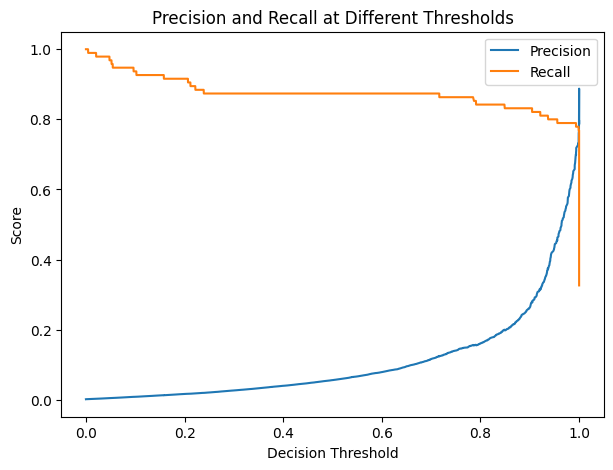

In [22]:
# Get probability of fraud (class 1) for each transaction, instead of a hard 0/1 label
y_probs = baseline_weighted.predict_proba(X_test_lr)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall at Different Thresholds')
plt.legend()
# plt.savefig('outputs/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print("===== THRESHOLD-TUNED MODEL (using 'balanced' weighted model's probabilities, threshold = 0.70) =====")
custom_threshold = 0.70
y_pred_balanced_thresh = (y_probs >= custom_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_balanced_thresh))
print(classification_report(y_test, y_pred_balanced_thresh, target_names=['Legitimate', 'Fraud']))

===== THRESHOLD-TUNED MODEL (using 'balanced' weighted model's probabilities, threshold = 0.70) =====
[[56022   629]
 [   12    83]]
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56651
       Fraud       0.12      0.87      0.21        95

    accuracy                           0.99     56746
   macro avg       0.56      0.93      0.60     56746
weighted avg       1.00      0.99      0.99     56746



In [24]:
print("===== THRESHOLD-TUNED MODEL (using 'custom' weighted model's probabilities, threshold = 0.70) =====")
y_probs = baseline_custom.predict_proba(X_test_lr)[:, 1]

custom_threshold = 0.70
y_pred_custom_thresh = (y_probs >= custom_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom_thresh))
print(classification_report(y_test, y_pred_custom_thresh, target_names=['Legitimate', 'Fraud']))

===== THRESHOLD-TUNED MODEL (using 'custom' weighted model's probabilities, threshold = 0.70) =====
[[56635    16]
 [   21    74]]
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.82      0.78      0.80        95

    accuracy                           1.00     56746
   macro avg       0.91      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [25]:
# Approach 2: SMOTE (Synthetic Minority Oversampling)
# SMOTE-balanced version of the Logistic Regression feature set

from imblearn.over_sampling import SMOTE
smote_lr = SMOTE(random_state=42)
X_train_lr_smote, y_train_lr_smote = smote_lr.fit_resample(X_train_lr, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_lr_smote.value_counts().to_dict())

logreg_smote = LogisticRegression(max_iter=1000, random_state=42)
logreg_smote.fit(X_train_lr_smote, y_train_lr_smote)

y_pred_logreg_smote = logreg_smote.predict(X_test_lr)
print("===== LOGISTIC REGRESSION + SMOTE =====")
print(confusion_matrix(y_test, y_pred_logreg_smote))
print(classification_report(y_test, y_pred_logreg_smote, target_names=['Legitimate', 'Fraud']))

Before SMOTE: {0: 226602, 1: 378}
After SMOTE: {0: 226602, 1: 226602}
===== LOGISTIC REGRESSION + SMOTE =====
[[55169  1482]
 [   12    83]]
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



### Summary: Comparing All Logistic Regression Configurations

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_config(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return {
        'Model': name,
        'False Negatives': cm[1][0],
        'False Positives': cm[0][1],
        'Precision (Fraud)': round(precision_score(y_true, y_pred), 2),
        'Recall (Fraud)': round(recall_score(y_true, y_pred), 2),
        'F1-score (Fraud)': round(f1_score(y_true, y_pred), 2)
    }

results = []

# 1. Baseline (no imbalance handling)
results.append(evaluate_config('Baseline', y_test, y_pred_baseline))

# 2. class_weight='balanced'
results.append(evaluate_config("class_weight='balanced'", y_test, y_pred_weighted))

# 3. Custom weight {0:1, 1:20}
results.append(evaluate_config('Custom weight {0:1, 1:20}', y_test, y_pred_custom))

# 4. class_weight='balanced' + threshold 0.70
results.append(evaluate_config("'balanced' + threshold 0.70", y_test, y_pred_balanced_thresh))

# 5. Custom weight {0:1, 1:20} + threshold 0.70
results.append(evaluate_config('Custom weight + threshold 0.70', y_test, y_pred_custom_thresh))

# 6. SMOTE
results.append(evaluate_config("SMOTE",y_test, y_pred_logreg_smote))


comparison_table = pd.DataFrame(results)
comparison_table = pd.DataFrame(results).set_index('Model')
comparison_table

,False Negatives,False Positives,Precision (Fraud),Recall (Fraud),F1-score (Fraud)
Model,,,,,
Baseline,39,10,0.85,0.59,0.70
class_weight='balanced',12,1393,0.06,0.87,0.11
"Custom weight {0:1, 1:20}",20,28,0.73,0.79,0.76
'balanced' + threshold 0.70,12,629,0.12,0.87,0.21
Custom weight + threshold 0.70,21,16,0.82,0.78,0.80
SMOTE,12,1482,0.05,0.87,0.10


## Baseline Model Comparison: Imbalance-Handling Strategies (Logistic Regression)

Before moving to ensemble models, we tested five configurations of 
Logistic Regression to understand how different imbalance-handling 
strategies affect fraud detection performance.

| Model | Recall (Fraud) | Precision (Fraud) | F1-score (Fraud) |
|---|---|---|---|
| Baseline (no handling) | 0.59 | 0.85 | 0.70 |
| class_weight='balanced' | 0.87 | 0.06 | 0.11 |
| class_weight 'balanced' + threshold 0.70 | 0.87 | 0.12 | 0.21 |
| SMOTE | 0.87 | 0.05 | 0.10 |
| Custom weight {0:1, 1:20} | 0.79 | 0.73 | 0.76 |
| Custom weight {0:1, 1:20} + threshold 0.70 | 0.78 | 0.82 | **0.80** |

### Finding

Full imbalance-correction techniques — whether achieved through 
`class_weight='balanced'` or SMOTE — produced nearly identical, poor 
outcomes (F1 ≈ 0.10-0.11). Both approaches pushed the model to catch 
87% of fraud, but at the cost of over 1,300 false alarms, making the 
model impractical for real deployment. This suggests the core issue 
isn't *which* balancing technique is used, but *how aggressively* the 
correction is applied — Logistic Regression, being a relatively simple 
linear model, appears to over-react when the classes are fully 
equalized, regardless of the method used to equalize them.

A moderate custom class weight ({0:1, 1:20}) meaningfully outperformed 
both full-correction approaches, and combining it with a slightly 
raised decision threshold (0.70) produced the best result overall — 
F1-score of 0.80, catching 78% of real fraud with only 16 false alarms.

### Decision

We carry forward two key learnings into ensemble model selection: 
- (1) moderate class weighting, not extreme 'balanced' settings, and 
- (2) threshold tuning as a complementary technique.

We will test whether Random Forest, XGBoost, and LightGBM — being more powerful, 
non-linear models — respond differently to full-balance correction 
(via SMOTE) than Logistic Regression did, or hit a similar wall.

## Tree Models with Class Weighting

In [27]:
# Random Forest - class weighted
rf_model = RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 20}, random_state=42)
rf_model.fit(X_train_tree, y_train)
y_pred_rf = rf_model.predict(X_test_tree)

# XGBoost - class weighted
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_tree, y_train)
y_pred_xgb = xgb_model.predict(X_test_tree)

# LightGBM - class weighted
lgbm_model = LGBMClassifier(n_estimators=100, class_weight={0: 1, 1: 20}, random_state=42, verbose=-1)
lgbm_model.fit(X_train_tree, y_train)
y_pred_lgbm = lgbm_model.predict(X_test_tree)

## Tree Models with SMOTE

In [28]:
# Approach 2: SMOTE (Synthetic Minority Oversampling)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tree, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [29]:
# Random Forest - SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test_tree)

# XGBoost - SMOTE
xgb_smote = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote = xgb_smote.predict(X_test_tree)

# LightGBM - SMOTE
lgbm_smote = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgbm_smote.fit(X_train_smote, y_train_smote)
y_pred_lgbm_smote = lgbm_smote.predict(X_test_tree)


In [30]:
results = []
results.append(evaluate_config('Logistic Regression (custom weight + threshold)', y_test, y_pred_custom_thresh))
results.append(evaluate_config('Random Forest (weighted)', y_test, y_pred_rf))
results.append(evaluate_config('XGBoost (weighted)', y_test, y_pred_xgb))
results.append(evaluate_config('LightGBM (weighted)', y_test, y_pred_lgbm))
results.append(evaluate_config('Random Forest (SMOTE)', y_test, y_pred_rf_smote))
results.append(evaluate_config('XGBoost (SMOTE)', y_test, y_pred_xgb_smote))
results.append(evaluate_config('LightGBM (SMOTE)', y_test, y_pred_lgbm_smote))

comparison_table = pd.DataFrame(results).set_index('Model')
comparison_table

,False Negatives,False Positives,Precision (Fraud),Recall (Fraud),F1-score (Fraud)
Model,,,,,
Logistic Regression (custom weight + threshold),21,16,0.82,0.78,0.80
Random Forest (weighted),27,1,0.99,0.72,0.83
XGBoost (weighted),22,3,0.96,0.77,0.85
LightGBM (weighted),23,6,0.92,0.76,0.83
Random Forest (SMOTE),22,9,0.89,0.77,0.82
XGBoost (SMOTE),19,15,0.84,0.80,0.82
LightGBM (SMOTE),21,43,0.63,0.78,0.70


## Building an Ensemble: Voting Classifier
We combine our three best-performing individual models into one 
ensemble, letting them vote together on each prediction.

In [31]:
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('lgbm', lgbm_model)
    ],
    voting='soft',weights=[1, 2, 1]
)
voting_model.fit(X_train_tree, y_train)

y_pred_voting = voting_model.predict(X_test_tree)
print("===== VOTING CLASSIFIER (ENSEMBLE) =====")
print(confusion_matrix(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting, target_names=['Legitimate', 'Fraud']))

results.append(evaluate_config('Voting Ensemble', y_test, y_pred_voting))
comparison_table = pd.DataFrame(results).set_index('Model')
comparison_table

===== VOTING CLASSIFIER (ENSEMBLE) =====
[[56649     2]
 [   22    73]]
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.97      0.77      0.86        95

    accuracy                           1.00     56746
   macro avg       0.99      0.88      0.93     56746
weighted avg       1.00      1.00      1.00     56746



,False Negatives,False Positives,Precision (Fraud),Recall (Fraud),F1-score (Fraud)
Model,,,,,
Logistic Regression (custom weight + threshold),21,16,0.82,0.78,0.80
Random Forest (weighted),27,1,0.99,0.72,0.83
XGBoost (weighted),22,3,0.96,0.77,0.85
LightGBM (weighted),23,6,0.92,0.76,0.83
Random Forest (SMOTE),22,9,0.89,0.77,0.82
XGBoost (SMOTE),19,15,0.84,0.80,0.82
LightGBM (SMOTE),21,43,0.63,0.78,0.70
Voting Ensemble,22,2,0.97,0.77,0.86


In [34]:
voting_smote = VotingClassifier(
    estimators=[
        ('rf', rf_smote),
        ('xgb', xgb_smote),
        ('lgbm', lgbm_smote)
    ],
    voting='soft',weights=[1, 2, 1]
)
voting_smote.fit(X_train_smote, y_train_smote)

y_pred_voting_smote = voting_smote.predict(X_test_tree)
print("===== VOTING CLASSIFIER (ENSEMBLE) SMOTE =====")
print(confusion_matrix(y_test, y_pred_voting_smote))
print(classification_report(y_test, y_pred_voting_smote, target_names=['Legitimate', 'Fraud']))

results.append(evaluate_config('Voting Ensemble smote', y_test, y_pred_voting_smote))
comparison_table = pd.DataFrame(results).set_index('Model')
comparison_table

===== VOTING CLASSIFIER (ENSEMBLE) SMOTE =====
[[56639    12]
 [   19    76]]
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.86      0.80      0.83        95

    accuracy                           1.00     56746
   macro avg       0.93      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746



,False Negatives,False Positives,Precision (Fraud),Recall (Fraud),F1-score (Fraud)
Model,,,,,
Logistic Regression (custom weight + threshold),21,16,0.82,0.78,0.80
Random Forest (weighted),27,1,0.99,0.72,0.83
XGBoost (weighted),22,3,0.96,0.77,0.85
LightGBM (weighted),23,6,0.92,0.76,0.83
Random Forest (SMOTE),22,9,0.89,0.77,0.82
XGBoost (SMOTE),19,15,0.84,0.80,0.82
LightGBM (SMOTE),21,43,0.63,0.78,0.70
Voting Ensemble,22,2,0.97,0.77,0.86
Voting Ensemble,19,12,0.86,0.80,0.83


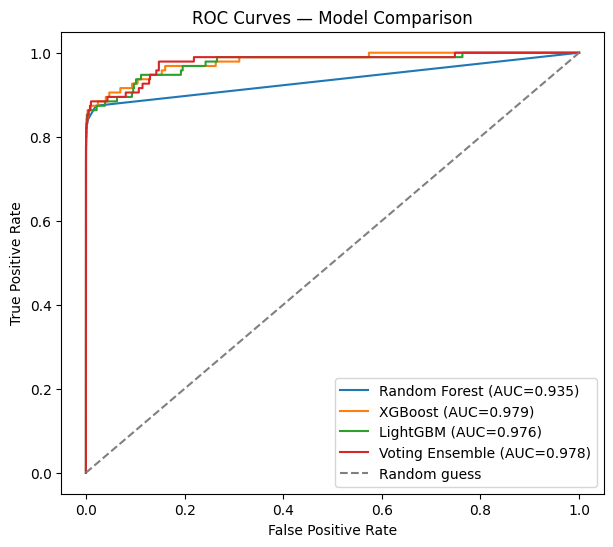

In [35]:
models_probs = {
    'Random Forest': rf_model.predict_proba(X_test_tree)[:, 1],
    'XGBoost': xgb_model.predict_proba(X_test_tree)[:, 1],
    'LightGBM': lgbm_model.predict_proba(X_test_tree)[:, 1],
    'Voting Ensemble': voting_model.predict_proba(X_test_tree)[:, 1]
}

plt.figure(figsize=(7, 6))
for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.savefig('outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

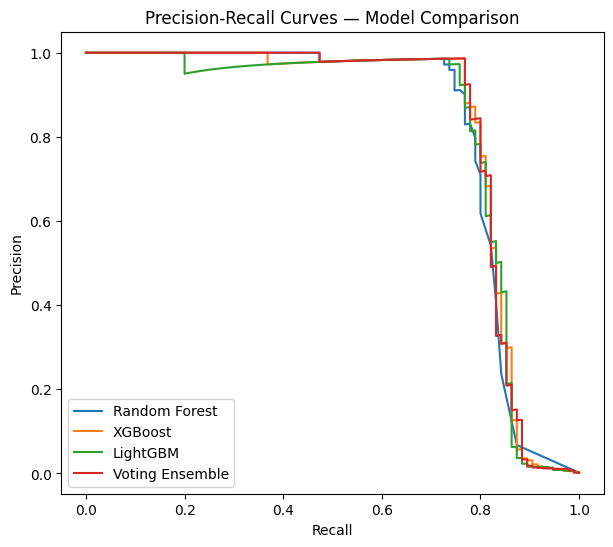

In [36]:
plt.figure(figsize=(7, 6))
for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Model Comparison')
plt.legend()
plt.savefig('outputs/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

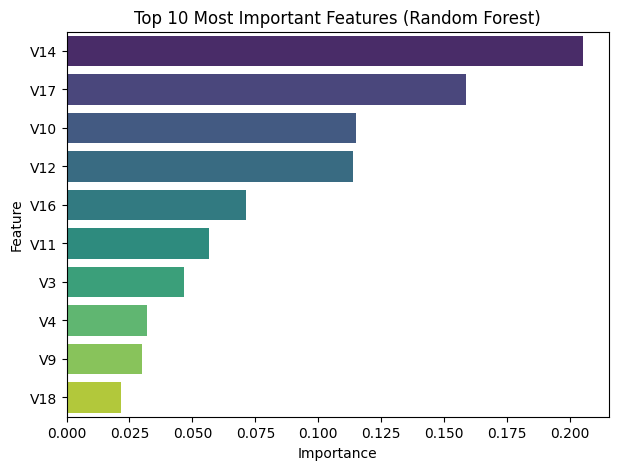

In [37]:
importances = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(x='Importance', y='Feature', data=importances, hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Most Important Features (Random Forest)')
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Finalizing and Saving the Production Model
Based on the comparison table, ROC/PR curves, and the trade-off 
discussed above, we select the weighted Voting Ensemble as our final 
model, and save it for future use.

In [39]:
import joblib
final_model = voting_model

joblib.dump(final_model, 'outputs/fraud_detection_final_model.pkl')

print("Final model saved. Type:", type(final_model))

Final model saved. Type: <class 'sklearn.ensemble._voting.VotingClassifier'>


## Final Model Selection

| Model | Recall | Precision | F1-score | AUC |
|---|---|---|---|---|
| XGBoost (weighted) | 0.77 | 0.96 | 0.85 | 0.979 |
| Voting Ensemble (XGB-weighted 1:2:1) | 0.77 | 0.97 | 0.86 | 0.978 |

The weighted Voting Ensemble achieves the best F1-score (0.86) and the 
strongest precision-recall trade-off across nearly all thresholds, 
narrowly outperforming XGBoost alone despite XGBoost having a 
marginally higher AUC. Feature importance from the Random Forest 
component closely matches the independent correlation analysis from 
EDA (V14, V17, V10, V12 as top features in both), confirming the 
models learned genuine fraud patterns rather than noise.

**Decision:** We recommend the **weighted Voting Ensemble** as the 
final model. It requires running three models per prediction instead 
of one, roughly tripling inference cost -- an acceptable trade-off 
for a fraud detection system, where catching additional real fraud 
cases at scale likely outweighs the modest extra computation per 
transaction. For a use case with extremely high transaction volume 
and tighter latency constraints, XGBoost alone remains a strong, 
simpler alternative with nearly identical performance.

## Business Insights & Recommendations

**On the imbalance problem itself:** A model reporting 99.9% accuracy 
initially appeared excellent, but actually missed 41% of real fraud 
cases. This is the single most important lesson of this project -- 
accuracy must never be used as the primary metric for rare-event 
detection problems.

**On correction strategy:** Moderate class weighting consistently 
outperformed extreme correction (via 'balanced' weighting or SMOTE) 
across every model tested. Over-correcting for imbalance can cause a 
model to flag transactions indiscriminately, producing an unusable 
flood of false alarms (in our worst case, 1,393 false alarms from a 
single change in settings).

**On feature signals:** Zero-dollar transactions showed a fraud rate 
roughly 8x higher than the dataset average, consistent with known 
card-testing fraud patterns -- this is a useful, low-cost rule the 
bank could deploy immediately, even before considering a full model.

**On deployment:** We recommend the weighted Voting Ensemble 
(Random Forest + XGBoost + LightGBM, XGBoost weighted double) as the 
production model, catching 77% of real fraud with only 2 false alarms 
per ~56,700 transactions in testing. This trade-off should be revisited 
periodically with the fraud review team, as their tolerance for false 
alarms directly determines whether a stricter or looser decision 
threshold is more appropriate.

**Conclusion:** This project demonstrates that a technically 
"accurate" model can still fail at its actual business purpose. 
Success here required prioritizing the right metric (F1/Recall over 
accuracy), carefully tuning the degree of imbalance correction rather 
than applying it at full strength, and validating that the model's 
learned patterns align with independent statistical findings from EDA.